#  Denoising Images with an Encoder-Decoder


<div style="background-color: #f0f8ff; border: 2px solid #4682b4; padding: 10px;">
<a href="https://colab.research.google.com/github/DeepTrackAI/DeepLearningCrashCourse/blob/main/Ch04_AE/ec04_1_denoising/denoising.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
<strong>If using Colab/Kaggle:</strong> You need to uncomment the code in the cell below this one.
</div>

In [1]:
# !pip install deeplay deeptrack  # Uncomment if using Colab/Kaggle.

This notebook provides you with a complete code example that generates noisy brightfield microscopy images of particles, trains an encoder-decoder to denoise them, and visualizes the results.

<div style="background-color: #f0f8ff; border: 2px solid #4682b4; padding: 10px;">
<strong>Note:</strong> This notebook contains the Code Example 4-1 from the book  

**Deep Learning Crash Course**  
Giovanni Volpe, Benjamin Midtvedt, Jesús Pineda, Henrik Klein Moberg, Harshith Bachimanchi, Joana B. Pereira, Carlo Manzo  
No Starch Press, San Francisco (CA), 2026  
ISBN-13: 9781718503922  

[https://nostarch.com/deep-learning-crash-course](https://nostarch.com/deep-learning-crash-course)

You can find the other notebooks on the [Deep Learning Crash Course GitHub page](https://github.com/DeepTrackAI/DeepLearningCrashCourse).
</div>

## Generating the Data

Define a spherical particle ...

In [2]:
import deeptrack as dt
import deeplay as dl
import numpy as np

particle = dt.Sphere(
    position=np.array([0.5, 0.5]) * 64, position_unit="pixel",
    radius=500 * dt.units.nm, refractive_index=1.45 + 0.02j,
)

c:\Users\jojac\anaconda3\envs\stoch\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


... define the microscope to observe the particle ...

In [3]:
brightfield_microscope = dt.Brightfield(
    wavelength=500 * dt.units.nm, NA=1.0, resolution=1 * dt.units.um,
    magnification=10, refractive_index_medium=1.33,
    output_region=(0, 0, 64, 64),
)

... obtain the image of the microscopic particle ...

In [4]:
illuminated_sample = brightfield_microscope(particle)

... simulate the clean image of the particle ...

In [5]:
import torch

clean_particle = (illuminated_sample >> dt.NormalizeMinMax()
                  >> dt.MoveAxis(2, 0)
                  >> dt.pytorch.ToTensor(dtype=torch.float))

... simulate the noisy image of the particle ...

In [6]:
# noise = dt.Poisson(snr=lambda: 2.0 + np.random.rand())
noise = dt.Poisson(snr=lambda: 4.0 + np.random.rand())

noisy_particle = (illuminated_sample >> noise >> dt.NormalizeMinMax()
                  >> dt.MoveAxis(2, 0)
                  >> dt.pytorch.ToTensor(dtype=torch.float))

... combine the noisy and clean particle images into a single simulation pipeline ...

In [7]:
pip = noisy_particle & clean_particle

... and plot a few noisy and corresponding clean particle images.

In [8]:
import matplotlib.pyplot as plt

def plot_image(title, image):
    """Plot a grayscale image with a title."""
    plt.imshow(image, cmap="gray")
    plt.title(title, fontsize=30)
    plt.axis("off")
    plt.show()

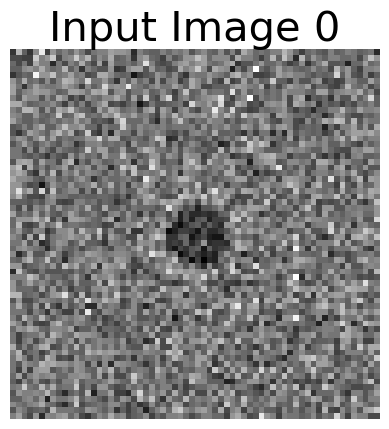

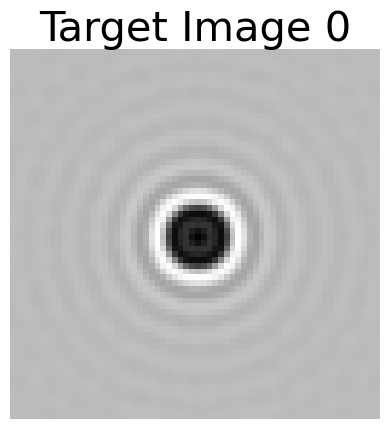

In [9]:
for i in range(1):
    input, target = pip.update().resolve()
    plot_image(f"Input Image {i}", input.permute(1, 2, 0))
    plot_image(f"Target Image {i}", target.permute(1, 2, 0))

## Creating a Simulated Dataset

Define a class representing a simulated dataset to generate the data for the training of the denoising encoder-decoder ...

In [10]:
class SimulatedDataset(torch.utils.data.Dataset):
    """Simulated dataset simulating pairs of noisy and clean images."""

    def __init__(self, pip, buffer_size, replace=0):
        """Initialize the dataset."""
        self.pip, self.replace = pip, replace
        self.images = [pip.update().resolve() for _ in range(buffer_size)]

    def __len__(self):
        """Return the size of the image buffer."""
        return len(self.images)

    def __getitem__(self, idx):
        """Retrieve a noisy-clean image pair from the dataset."""
        if np.random.rand() < self.replace:
            self.images[idx] = self.pip.update().resolve()
        image_pair = self.images[idx]
        noisy_image, clean_image = image_pair[0], image_pair[1]
        return noisy_image, clean_image

... and create the dataset and the data loader.

In [11]:
dataset = SimulatedDataset(pip, buffer_size=256, replace=0.1)
loader = torch.utils.data.DataLoader(dataset, batch_size=8, shuffle=True)

## Checking Absence of Mode Collapse

Use the trained encoder-decoder with a blank image.

## Checking Generalization Capabilities

Define a pipeline with a particle with varying position and radius ...

In [12]:
# diverse_particle = dt.Sphere(
#     position=lambda: np.array([0.2, 0.2] + np.random.rand(2) * 0.6) * 64,
#     radius=lambda: 500 * dt.units.nm * (1 + np.random.rand()),
#     position_unit="pixel",
#     refractive_index=1.45 + 0.02j,
# )
diverse_particle = dt.Sphere(
    position=lambda: np.array([0.5, 0.5]) * 64,
    radius=lambda: 500 * dt.units.nm * (1 + np.random.rand()),
    position_unit="pixel",
    refractive_index=1.45 + 0.02j,
)
diverse_illuminated_sample = brightfield_microscope(diverse_particle)
diverse_clean_particle = (diverse_illuminated_sample >> dt.NormalizeMinMax()
                          >> dt.MoveAxis(2, 0)
                          >> dt.pytorch.ToTensor(dtype=torch.float))
diverse_noisy_particle = (diverse_illuminated_sample >> noise 
                          >> dt.NormalizeMinMax() >> dt.MoveAxis(2, 0)
                          >> dt.pytorch.ToTensor(dtype=torch.float))
diverse_pip = diverse_noisy_particle & diverse_clean_particle

## Improving the Training

Train with the dataset with varying parameters ...

In [24]:
diverse_dataset = SimulatedDataset(diverse_pip, buffer_size=256, replace=0.1)
diverse_loader = torch.utils.data.DataLoader(diverse_dataset, batch_size=8,
                                             shuffle=True)
# diverse_ed = regressor_template.create()



diverse_ed = dl.VariationalAutoEncoder(
    input_size=(64, 64), latent_dim=2, channels=[16, 16],
    reconstruction_loss=torch.nn.BCELoss(reduction="sum"), beta=1,
)

mlp_hidden = [8,4]
diverse_ed.fc_mu = dl.MultiLayerPerceptron(
    in_features=64*64, hidden_features=mlp_hidden, out_features=2,
    out_activation=None
)
diverse_ed.fc_var = dl.MultiLayerPerceptron(
    in_features=64*64, hidden_features=mlp_hidden, out_features=2,
    out_activation=None
)
diverse_ed.fc_dec = dl.MultiLayerPerceptron(
    in_features=2, hidden_features=mlp_hidden, out_features=64*64,
    out_activation=None
)

diverse_ed = diverse_ed.create()


print(diverse_ed)



VariationalAutoEncoder(
  (encoder): ConvolutionalEncoder2d(
    (blocks): LayerList(
      (0): Conv2dBlock(
        (layer): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (activation): ReLU()
      )
      (1): Conv2dBlock(
        (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (layer): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (activation): ReLU()
      )
      (2): Conv2dBlock(
        (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (layer): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (activation): Identity()
      )
    )
    (postprocess): Flatten(start_dim=1, end_dim=-1)
  )
  (fc_mu): MultiLayerPerceptron(
    (blocks): LayerList(
      (0): LinearBlock(
        (layer): Linear(in_features=4096, out_features=8, bias=True)
        (activation): ReLU()
      )
      (1): LinearBlock(
        (layer): Linear

In [25]:
diverse_ed_trainer = dl.Trainer(max_epochs=150, accelerator="auto")
diverse_ed_trainer.fit(diverse_ed, diverse_loader)

c:\Users\jojac\anaconda3\envs\stoch\Lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.


┏━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                ┃ Type                   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder             │ ConvolutionalEncoder2d │  4.8 K │ train │     0 │
│ 1 │ fc_mu               │ MultiLayerPerceptron   │ 32.8 K │ train │     0 │
│ 2 │ fc_var              │ MultiLayerPerceptron   │ 32.8 K │ train │     0 │
│ 3 │ fc_dec              │ MultiLayerPerceptron   │ 20.5 K │ train │     0 │
│ 4 │ decoder             │ ConvolutionalDecoder2d │  6.9 K │ train │     0 │
│ 5 │ reconstruction_loss │ BCELoss                │      0 │ train │     0 │
│ 6 │ train_metrics       │ MetricCollection       │      0 │ train │     0 │
│ 7 │ val_metrics         │ MetricCollection       │      0 │ train │     0 │
│ 8 │ test_metrics        │ MetricCollection       │      0 │ train │     0 │
│ 9 │ optimizer           │ Adam                   │      0 │ train │     0 │
└───┴─────────────────────┴────────────────────────┴────────┴───────┴───────┘

Trainable params: 97.8 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 97.8 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 66                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

c:\Users\jojac\anaconda3\envs\stoch\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\jojac\anaconda3\envs\stoch\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
c:\Users\jojac\anaconda3\envs\stoch\Lib\site-packages\lightning\pytorch\loops\fit_loop.py:317: The number of training batches (32) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 149: 100%|██████████| 32/32 [00:00<00:00, 36.10it/s, v_num=22, train_rec_loss_step=1.92e+4, train_KL_step=30.70, train_total_loss_step=1.92e+4, train_rec_loss_epoch=1.9e+4, train_KL_epoch=35.60, train_total_loss_epoch=1.9e+4]  


... and plot the images obtained with the improved training.

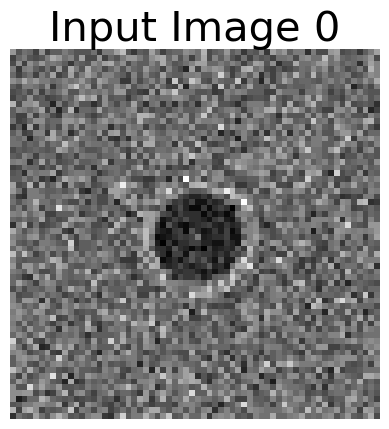

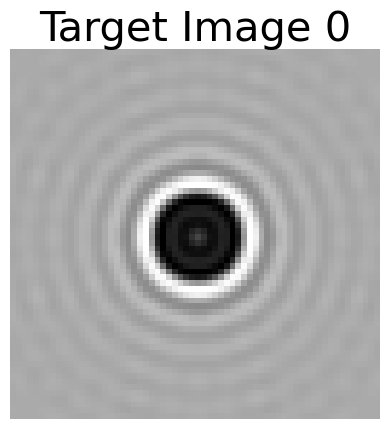

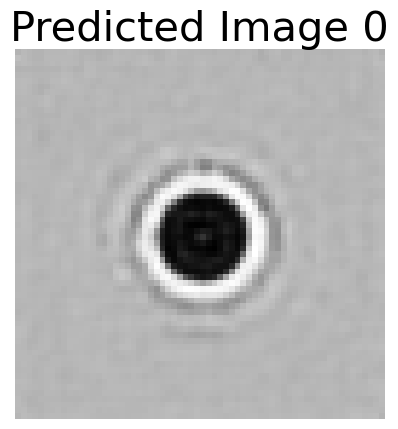

In [26]:
for i in range(1):
    diverse_input, diverse_target = diverse_pip.update().resolve()
    diverse_predicted = diverse_ed(diverse_input.unsqueeze(0))[0].detach()

    plot_image(f"Input Image {i}", diverse_input[0, :, :])
    plot_image(f"Target Image {i}", diverse_target[0, :, :])
    plot_image(f"Predicted Image {i}", diverse_predicted[0, 0, :, :])

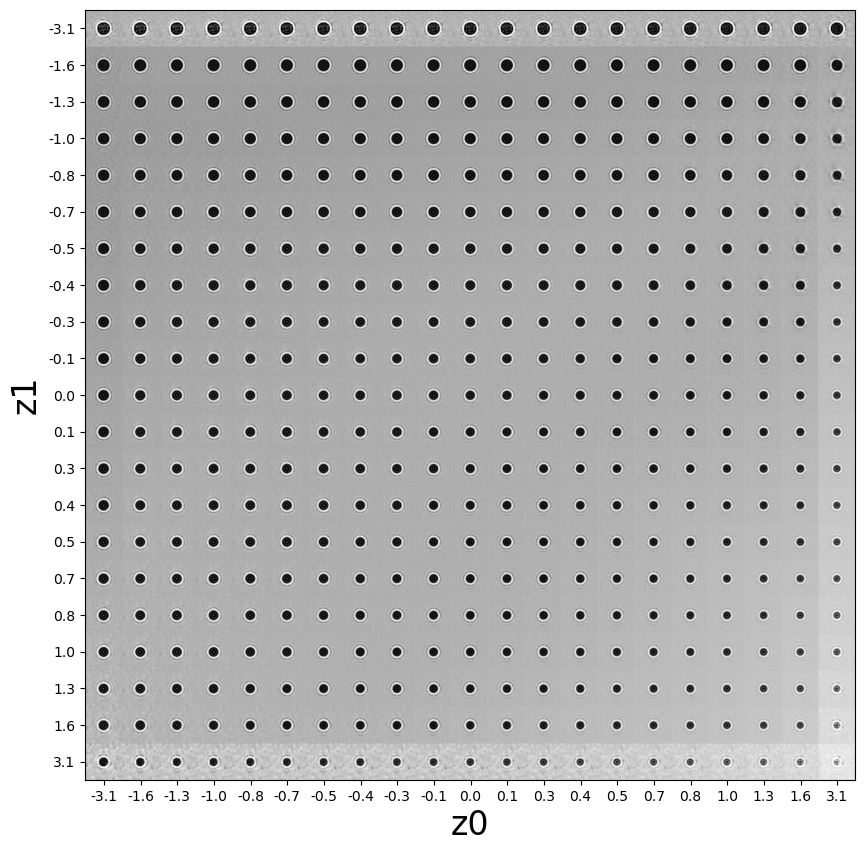

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from torch.distributions.normal import Normal

img_num, img_size = 21, 64
z0_grid = z1_grid = Normal(0, 1).icdf(torch.linspace(0.001, 0.999, img_num))

image = np.zeros((img_num * img_size, img_num * img_size))
for i0, z0 in enumerate(z0_grid):
    for i1, z1 in enumerate(z1_grid):
      z = torch.stack((z0, z1)).unsqueeze(0)
      generated_image = diverse_ed.decode(z).clone().detach()
      image[i1 * img_size : (i1 + 1) * img_size,
            i0 * img_size : (i0 + 1) * img_size] = \
          generated_image.numpy().squeeze()

plt.figure(figsize=(10, 10))
plt.imshow(image, cmap="gray")
plt.xlabel("z0", fontsize=24)
plt.xticks(np.arange(0.5 * img_size, (0.5 + img_num) * img_size, img_size),
           np.round(z0_grid.numpy(), 1))
plt.ylabel("z1", fontsize=24)
plt.yticks(np.arange(0.5 * img_size, (0.5 + img_num) * img_size, img_size),
           np.round(z1_grid.numpy(), 1))
plt.show()

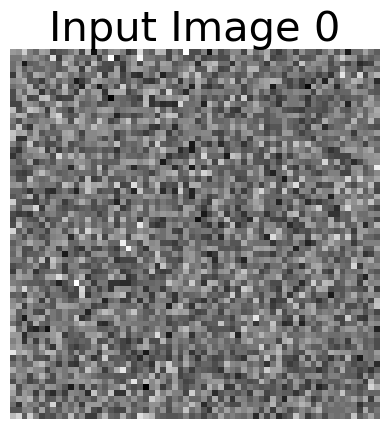

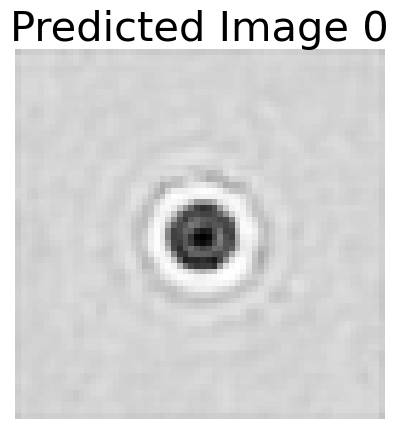

In [28]:
blank = brightfield_microscope(particle ^ 0)
blank_pip = (blank >> noise >> dt.NormalizeMinMax() >> dt.MoveAxis(2, 0)
             >> dt.pytorch.ToTensor(dtype=torch.float))

for i in range(1):
    blank_image = blank_pip.update().resolve()
    blank_predicted = diverse_ed(blank_image.unsqueeze(0))[0].detach()

    plot_image(f"Input Image {i}", blank_image[0, :, :])
    plot_image(f"Predicted Image {i}", blank_predicted[0, 0, :, :])